In [1]:
import torch
from src.model_unet import UNet,UnetGenerator
from src.DWM.data_setup import get_test_loader,get_watermark_img
from src.DWM.engine import *
from src.DWM.deep_watermark import *
import os

save_result = rf'runs2\watermark_new/flower_rgb_32_new2'
print(save_result.split('/'))
name = save_result.split('/')
name = name[-1]
folder_name = rf'images_new/{name}'
os.makedirs(folder_name,exist_ok=True)

wm_size = (32,32)
round_wm = False
wm_channel = 3
img_wm = get_watermark_img(rf'datasets\watermark_img\Spring-flowers-clipart-free-clipart-images.png',
                           wm_size,
                           convert='RGB',
                           round=round_wm)
val_path = rf'datasets\new_noise_dataset2\test'
dataloader = get_test_loader(val_path,
                            batch_size=1,
                            imgsize=(256,256),
                            convert='RGB')



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sk = torch.ones((1,)+wm_size)

model_H = UnetGenerator(input_nc=3,output_nc=3).to(device)
model_ = UnetGenerator(input_nc=3,output_nc=3).to(device)
model_E = Extraction(wh=wm_size,
                        input_Eb=1,
                        output_Eb=1,
                        WH=(256,256),
                        input_Ea=3,
                        output_nc=wm_channel,
                        input_inception=8).to(device)

call_back = Callback(patience=20)



['runs2\\watermark_new', 'flower_rgb_32_new2']


In [2]:
def load_model(path,model):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['state_dict'])

    return model

In [3]:
model_H = load_model(save_result+'/H/best.pt',model_H)

model_E = load_model(save_result+'/E/best.pt',model_E)


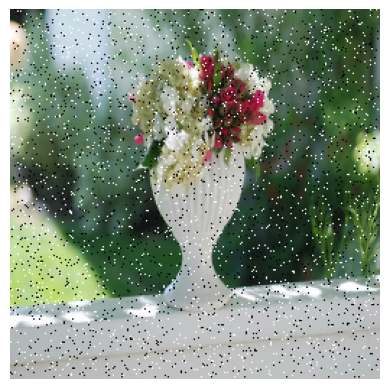

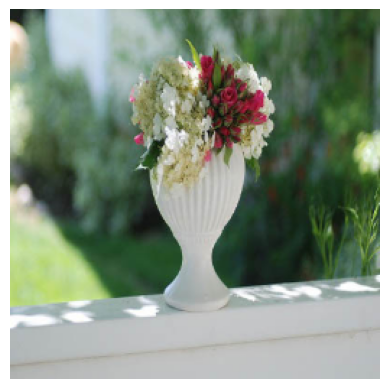

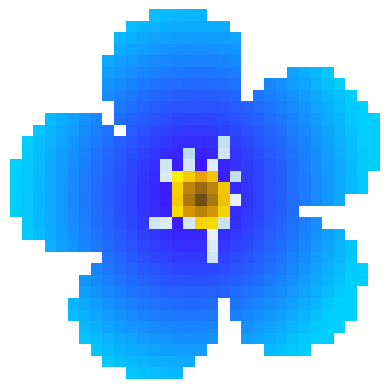

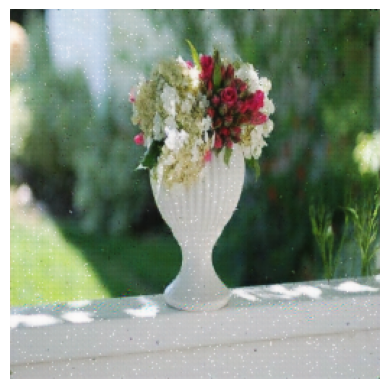

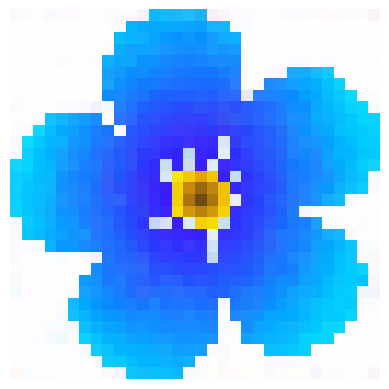

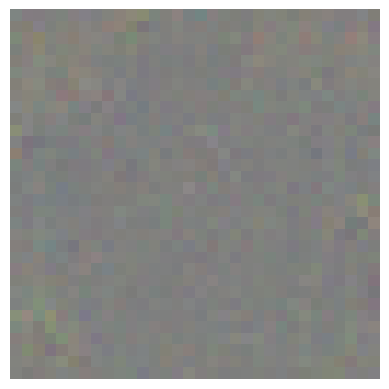

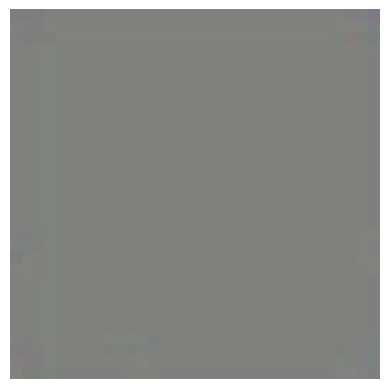

In [4]:
import matplotlib.pyplot as plt
model_H.eval() 
model_E.eval()
for i,(input,target) in enumerate(dataloader):


    input,target = input.to(device),target.to(device)
    secret_key_batch = sk.unsqueeze(0).repeat(input.size(0), 1, 1, 1).to(device)
    watermark_batch = img_wm.unsqueeze(0).repeat(input.size(0), 1, 1, 1).to(device)
    rkey = torch.rand_like(secret_key_batch).to(device)


    plt.imshow(np.transpose(input[0].detach().cpu().numpy(),(1,2,0)),cmap='gray')
    plt.axis('off')
    plt.savefig(rf'{folder_name}/input.png',bbox_inches='tight')
    plt.show()

    plt.imshow(np.transpose(target[0].detach().cpu().numpy(),(1,2,0)),cmap='gray')
    plt.axis('off')
    plt.savefig(rf'{folder_name}/target.png',bbox_inches='tight')
    plt.show()

    if img_wm.shape[0] == 1:

        plt.imshow(img_wm[0].detach().cpu().numpy(),cmap='gray')
    else:
        plt.imshow(np.transpose(img_wm.detach().cpu().numpy(),(1,2,0)),cmap='gray')
    plt.axis('off')
    plt.savefig(rf'{folder_name}/target_watermark.png',bbox_inches='tight')
    plt.show()

    # input_h = torch.cat([input,watermark_batch],dim=1)
    generated_imgs = model_H(input)
    plt.imshow(np.transpose(generated_imgs[0].detach().cpu().numpy(),(1,2,0)),cmap='gray')
    plt.axis('off')
    plt.savefig(rf'{folder_name}/output.png',bbox_inches='tight')
    plt.show()


    # _imgs = model_(input)
    # plt.imshow(np.transpose(_imgs[0].detach().cpu().numpy(),(1,2,0)),cmap='gray')
    # plt.axis('off')
    # plt.savefig(rf'no_embeding',bbox_inches='tight')
    # plt.show()

    
    watermark_extract = model_E(generated_imgs,secret_key_batch)

    if watermark_extract.shape[1] == 1:
        watermark_extract = watermark_extract[0,0].detach().cpu().numpy()

        if round_wm:
            watermark_extract = np.round(watermark_extract)


        plt.imshow(watermark_extract,cmap='gray')
    else:
        plt.imshow(np.transpose(watermark_extract[0].detach().cpu().numpy(),(1,2,0)))
    
    
    plt.axis('off')
    plt.savefig(rf'{folder_name}/watermark_ext.png',bbox_inches='tight')
    plt.show()


    watermark_r = model_E(generated_imgs,rkey)
    
    if watermark_r.shape[1] == 1:
        watermark_r = watermark_r[0,0].detach().cpu().numpy()

        if round_wm:
            watermark_r = np.round(watermark_r)


        plt.imshow(watermark_r,cmap='gray')
    else:
        plt.imshow(np.transpose(watermark_r[0].detach().cpu().numpy(),(1,2,0)))
    plt.axis('off')
    plt.savefig(rf'{folder_name}/watermark_wrongkey.png',bbox_inches='tight')
    plt.show()


    watermark_e = model_E(target,secret_key_batch)
    
    if watermark_e.shape[1] == 1:
        watermark_e = watermark_e[0,0].detach().cpu().numpy()

        if round_wm:
            watermark_e = np.round(watermark_e)


        plt.imshow(watermark_e,cmap='gray')
    else:
        plt.imshow(np.transpose(watermark_e[0].detach().cpu().numpy(),(1,2,0)))
    plt.axis('off')
    plt.savefig(rf'{folder_name}/no_watermark.png',bbox_inches='tight')
    plt.show()

    break

    



    

In [5]:
1 -0.999845221638679

0.00015477836132105072